# <font color="brown">Guided Project, Day 2: Predicting Which Customers Will Churn</font>

## <font color="brown">Problem Statement</font>

### <font color="blue">Context</font>

Day 2 of the 3-day guided project. Yesterday's notebook merged the bank's source files and
grouped customers into five behavioral segments, purely descriptive, no prediction involved.
Today turns that into an actionable question: **which customers are actually likely to leave**,
and does knowing yesterday's segment genuinely help answer it?

### <font color="blue">Objective</font>

- Merge the same source data, plus yesterday's `customer_segments.csv`.
- Train a churn classifier, evaluated honestly (this is an imbalanced problem, accuracy alone
  would be misleading).
- Directly test whether `Customer_Segment` adds real predictive value on top of the raw features
  it was built from, not just assume it does because it sounds useful.
- Save each customer's predicted churn risk as `churn_risk_scores.csv`, the artifact Day 3 will
  read back in.

### <font color="blue">Data Dictionary</font>

Same five source files as Day 1, plus:

| File | Grain | Contents |
| --- | --- | --- |
| `customer_segments.csv` | 1 row / customer | `Customer_Segment`, Day 1's output |

`Target_Churned` lives in `customers_account_summary.csv`, 1 if the customer churned, 0 otherwise.

## <font color="brown">Importing Necessary Libraries</font>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    recall_score, precision_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, ConfusionMatrixDisplay,
)

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

## <font color="brown">Step 1: Reading and Merging the Source Files</font>

In [2]:
demographics = pd.read_csv("customers_demographics.csv")
bureau = pd.read_csv("customers_credit_bureau.csv")
account_summary = pd.read_csv("customers_account_summary.csv")
txn_short = pd.read_csv("customers_transaction_features_short_term.csv")
txn_long = pd.read_csv("customers_transaction_features_long_term.csv")
segments = pd.read_csv("customer_segments.csv")

customers = demographics.merge(bureau, on="Customer_ID", how="left")
customers = customers.merge(account_summary, on="Customer_ID", how="left")
customers = customers.merge(txn_short, on="Customer_ID", how="left")
customers = customers.merge(txn_long, on="Customer_ID", how="left")
customers = customers.merge(segments[["Customer_ID", "Customer_Segment"]], on="Customer_ID", how="left")

print("Merged table:", customers.shape[0], "rows x", customers.shape[1], "columns")
customers["Customer_Segment"].value_counts()

Merged table: 450000 rows x 114 columns


Customer_Segment
Everyday Active Transactors    134980
Young Digital Starters          90845
High-Value Multi-Product        89474
Affluent Low-Engagement         81074
At-Risk Declining Activity      53627
Name: count, dtype: int64

## <font color="brown">Step 2: How Imbalanced Is This Problem?</font>

In [3]:
churn_rate = customers["Target_Churned"].mean()
print(f"Overall churn rate: {churn_rate:.1%}")

customers["Target_Churned"].value_counts()

Overall churn rate: 9.5%


Target_Churned
0    407456
1     42544
Name: count, dtype: int64

**9.5% of customers churned, 42,544 out of 450,000.** A meaningfully imbalanced problem, roughly
1 churner for every 9 customers who stayed. Accuracy alone would be a poor scorecard here, a model
that just predicted "stays" for everyone would already be 90.5% accurate while catching zero
actual churners, so recall, precision, and PR-AUC (which accounts for the imbalance) matter far
more than accuracy for judging this model.

## <font color="brown">Step 3: A Few Data-Quality Fixes and One Engineered Feature</font>

The same data-entry-error cleanup and activity-decline feature from Day 1, rebuilt from scratch
here, this notebook does not assume Day 1's intermediate steps, only its final segment output.

In [4]:
customers.loc[customers["Age"] > 100, "Age"] = np.nan
customers.loc[customers["Annual_Income"] < 0, "Annual_Income"] = np.nan

recent_monthly_activity = customers["Total_Txn_Count_30D"]
baseline_monthly_activity = customers["Total_Txn_Count_365D"] / 12
customers["Activity_Decline_Ratio"] = (recent_monthly_activity / baseline_monthly_activity.clip(lower=0.1)).clip(upper=3)

## <font color="brown">Step 4: Selecting Features</font>

A focused, business-relevant set: account behavior, transaction activity, credit bureau signals,
and demographics, plus one categorical feature, yesterday's segment. Columns with no baked-in
relationship to churn (region, referral source, and similar) are left out on purpose, not because
they are guaranteed useless, but because a first model should start from features with a clear
business rationale, not everything available.

In [5]:
numeric_features = [
    "Age", "Annual_Income", "Years_As_Customer",
    "Total_Balance", "Checking_Balance", "Savings_Balance",
    "Num_Products_Held", "Account_Credit_Utilization_Pct", "Credit_Limit",
    "Overdraft_Count_12M", "Complaint_Count_12M", "Num_Service_Calls_12M",
    "Days_Since_Last_Transaction", "Num_Branch_Visits_12M", "Num_Mobile_Logins_12M", "Num_Web_Logins_12M",
    "Total_Txn_Count_30D", "Total_Txn_Count_365D", "Activity_Decline_Ratio",
    "Bureau_Score", "Credit_Utilization_Pct", "Debt_To_Income_Ratio", "Num_Delinquencies_12M",
    "Avg_Monthly_Fees_Paid",
]

for col in numeric_features:
    customers[col] = customers[col].fillna(customers[col].median())

model_table = customers[["Customer_ID", "Customer_Segment", "Target_Churned"] + numeric_features].copy()
segment_dummies = pd.get_dummies(model_table["Customer_Segment"], prefix="Segment", dtype=int)

print("Numeric features:", len(numeric_features))
print("Segment dummy columns:", list(segment_dummies.columns))

Numeric features: 24
Segment dummy columns: ['Segment_Affluent Low-Engagement', 'Segment_At-Risk Declining Activity', 'Segment_Everyday Active Transactors', 'Segment_High-Value Multi-Product', 'Segment_Young Digital Starters']


## <font color="brown">Step 5: Splitting the Data</font>

A 70/15/15 train/validation/test split, stratified on the target so all three splits keep the
same ~9% churn rate.

In [6]:
feature_columns_without_segment = numeric_features
feature_columns_with_segment = numeric_features + list(segment_dummies.columns)

X_all = pd.concat([model_table[numeric_features], segment_dummies], axis=1)
y_all = model_table["Target_Churned"]

X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, random_state=1, stratify=y_all
)
X_val_full, X_test_full, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=1, stratify=y_temp
)

print("Train:", X_train_full.shape[0], " Validation:", X_val_full.shape[0], " Test:", X_test_full.shape[0])
print("Train churn rate:", round(y_train_full.mean(), 4),
      "Val churn rate:", round(y_val.mean(), 4),
      "Test churn rate:", round(y_test.mean(), 4))

Train: 315000  Validation: 67500  Test: 67500
Train churn rate: 0.0945 Val churn rate: 0.0945 Test churn rate: 0.0945


## <font color="brown">Step 6: Two Models, With and Without the Segment</font>

The real test: train the identical model twice, once on the raw behavioral features alone, once
with `Customer_Segment` added, and compare on the **validation** set. If the segment is just a
repackaging of information the raw features already carry, the two should perform about the same.

In [7]:
def train_and_evaluate(feature_cols, label):
    model = HistGradientBoostingClassifier(random_state=1)
    model.fit(X_train_full[feature_cols], y_train_full)

    val_proba = model.predict_proba(X_val_full[feature_cols])[:, 1]
    val_pred = (val_proba >= 0.5).astype(int)

    print(f"--- {label} ---")
    print("Recall:   ", round(recall_score(y_val, val_pred), 4))
    print("Precision:", round(precision_score(y_val, val_pred), 4))
    print("F1:       ", round(f1_score(y_val, val_pred), 4))
    print("ROC-AUC:  ", round(roc_auc_score(y_val, val_proba), 4))
    print("PR-AUC:   ", round(average_precision_score(y_val, val_proba), 4))
    return model

model_without_segment = train_and_evaluate(feature_columns_without_segment, "Without Customer_Segment")
print()
model_with_segment = train_and_evaluate(feature_columns_with_segment, "With Customer_Segment")

--- Without Customer_Segment ---
Recall:    0.3739
Precision: 0.6475
F1:        0.4741
ROC-AUC:   0.8621
PR-AUC:    0.5209



--- With Customer_Segment ---
Recall:    0.3788
Precision: 0.6418
F1:        0.4764
ROC-AUC:   0.8624
PR-AUC:    0.5206


**Virtually identical: PR-AUC 0.5209 without the segment, 0.5206 with it.** Every other metric
tells the same story, recall, precision, F1, and ROC-AUC all move by less than half a percentage
point either way. Adding `Customer_Segment` did **not** meaningfully improve this model. That is
a real result worth sitting with, not glossing over, the next step checks whether the segment
is actually useless, or just redundant with information the raw features already carry.

## <font color="brown">Step 7: Where Does Customer_Segment Actually Rank?</font>

Permutation importance answers this directly: shuffle one feature, measure how much validation
PR-AUC drops. A feature the model genuinely relies on hurts badly when scrambled.

In [8]:
perm_result = permutation_importance(
    model_with_segment, X_val_full[feature_columns_with_segment], y_val,
    n_repeats=5, random_state=1, scoring="average_precision",
)
importance = pd.Series(perm_result.importances_mean, index=feature_columns_with_segment)
importance.sort_values(ascending=False).head(12)

Days_Since_Last_Transaction           0.120254
Total_Balance                         0.045792
Num_Products_Held                     0.037367
Segment_At-Risk Declining Activity    0.034341
Complaint_Count_12M                   0.010216
Credit_Limit                          0.007911
Total_Txn_Count_365D                  0.005178
Annual_Income                         0.005024
Overdraft_Count_12M                   0.003905
Savings_Balance                       0.003345
Years_As_Customer                     0.002562
Num_Web_Logins_12M                    0.002462
dtype: float64

**`Segment_At-Risk Declining Activity` lands 4th out of every feature in the model**, right
behind `Days_Since_Last_Transaction`, `Total_Balance`, and `Num_Products_Held`, individually a
genuinely important feature, exactly what Day 1 would predict. So why did Step 6 show almost no
improvement from adding it? Because those top three raw features (activity recency, balance,
product count) are the *same* signals the At-Risk segment was built from in the first place.
The model can already extract that pattern directly from the raw numbers; the segment label is a
convenient, interpretable summary of information the model already has access to, not a source of
new information on top of it. Both things are true at once: the segment is individually important,
**and** it is redundant for this model's accuracy. It remains valuable for Day 3, where a simple,
human-readable label matters more than incremental accuracy.

## <font color="brown">Step 8: Final Evaluation on the Test Set</font>

The test set has not been touched until now. Whichever model performed better on validation gets
one honest, final check here.

In [9]:
final_model = model_with_segment
final_features = feature_columns_with_segment

test_proba = final_model.predict_proba(X_test_full[final_features])[:, 1]
test_pred = (test_proba >= 0.5).astype(int)

print("Test Recall:   ", round(recall_score(y_test, test_pred), 4))
print("Test Precision:", round(precision_score(y_test, test_pred), 4))
print("Test F1:       ", round(f1_score(y_test, test_pred), 4))
print("Test ROC-AUC:  ", round(roc_auc_score(y_test, test_proba), 4))
print("Test PR-AUC:   ", round(average_precision_score(y_test, test_proba), 4))

Test Recall:    0.3804
Test Precision: 0.6413
Test F1:        0.4776
Test ROC-AUC:   0.8618
Test PR-AUC:    0.5224


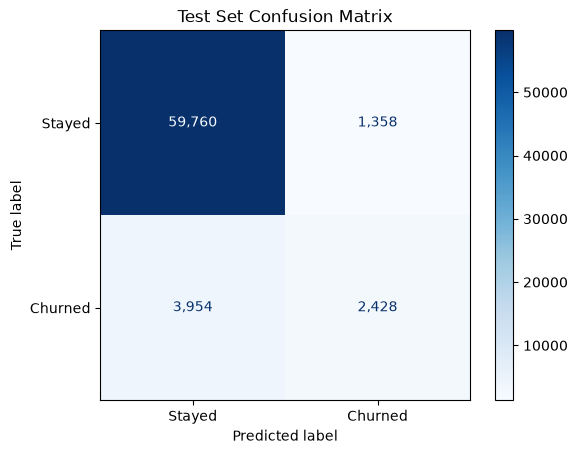

In [10]:
cm = confusion_matrix(y_test, test_pred)
ConfusionMatrixDisplay(cm, display_labels=["Stayed", "Churned"]).plot(cmap="Blues", values_format=",d")
plt.title("Test Set Confusion Matrix")
plt.show()

**Test performance closely matches validation** (PR-AUC 0.522 vs. 0.521, recall 38.0% vs. 37.9%),
no sign of overfitting to the validation set during model selection. In plain terms: this model
catches roughly 2 in 5 customers who actually go on to churn, at about 64% precision among the
customers it does flag, a real, usable starting point, not a finished product. At the default
0.5 probability threshold, only 5.5% of customers get flagged as high-risk, well under the true
9.5% churn rate, meaning the threshold could be lowered to catch more churners, at the cost of
more false alarms, a business tradeoff worth revisiting rather than a fixed rule.

## <font color="brown">Step 9: Saving Churn Risk Scores for Day 3</font>

Every customer, not just the test set, gets a predicted churn probability from the final model,
Day 3 needs this for the whole customer base to build its recommendations.

In [11]:
X_all_final = X_all[final_features]
customers["Churn_Risk_Score"] = final_model.predict_proba(X_all_final)[:, 1]

risk_output = customers[["Customer_ID", "Churn_Risk_Score"]].copy()
risk_output["High_Risk_Flag"] = (risk_output["Churn_Risk_Score"] >= 0.5).astype(int)
risk_output.to_csv("churn_risk_scores.csv", index=False)

print("Saved churn_risk_scores.csv:", risk_output.shape[0], "rows")
print("Flagged high-risk:", risk_output["High_Risk_Flag"].sum(), f"({risk_output['High_Risk_Flag'].mean():.1%})")
risk_output.head()

Saved churn_risk_scores.csv: 450000 rows
Flagged high-risk: 24725 (5.5%)


,Customer_ID,Churn_Risk_Score,High_Risk_Flag
0,CUST_0000000,0.084275,0
1,CUST_0000001,0.013918,0
2,CUST_0000002,0.226875,0
3,CUST_0000003,0.040099,0
4,CUST_0000004,0.013745,0


## <font color="brown">Business Insights and Recommendations</font>

- **The model catches roughly 38% of customers who will actually churn, at 64% precision**, on a
  held-out test set. A real, usable starting point for a retention program, not a finished
  product, there is real room to improve recall further (more features, threshold tuning, or a
  cost-sensitive approach) before this goes into production.
- **`Customer_Segment` is individually important (4th overall) but not incrementally useful**:
  adding it barely changed the model's accuracy, because it summarizes signal (activity decline,
  balance, product count) the model already sees directly. Business teams get a clean, readable
  label; the model itself doesn't need it to perform well. Both are legitimate, separate reasons
  to keep the segment around.
- **Activity recency, balance, and product count are the real drivers of churn risk**, exactly
  the same signals that defined the "At-Risk Declining Activity" segment on Day 1, two independent
  analyses (unsupervised segmentation, supervised prediction) converging on the same underlying
  behavior is a meaningful cross-check, not a coincidence.
- **The default 0.5 threshold under-flags risk relative to the true churn rate** (5.5% flagged
  vs. 9.5% actual), worth revisiting deliberately based on the retention team's actual capacity
  and the cost of a false alarm versus a missed churner.
- **Every customer's churn risk score is now available for Day 3**, which will use it, alongside
  Day 1's segment, to decide which product to recommend, and to whom retention efforts should be
  targeted first.